# Load an MLP model and convert it to ONNX file
Please take the following steps before running this notebook
1. clone the repo by running `git clone https://github.com/abidihaider/RealTimeAlignment.git`
2. check to the develop branch of the repo
3. run `python setup.py develop`

In [63]:
import sys
from pathlib import Path
import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import onnx
import onnxruntime

from rtal.datasets.dataset import ROMDataset
from torch.utils.data import DataLoader

from mlp import MLP

In [6]:
device = 'cpu'

## Load some data

In [ ]:
data_root = 'data/rom_det-3_part-200_cont-and-rounded_excerpt/'
dataset  = ROMDataset(data_root, split='train', num_particles=50)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

## Load model configuration and use it to initialize a model

In [39]:
with open('checkpoints/config.yaml', 'r', encoding='UTF-8') as handle:
    config = yaml.safe_load(handle)

model_full = MLP(**config['model'])
model_half = MLP(**config['model'])

In [40]:
ckpt_path = 'checkpoints/ckpt_last.path'
ckpt = torch.load(ckpt_path, map_location='cpu')
model_state_dict = ckpt['model']

model_full.load_state_dict(model_state_dict)
model_half.load_state_dict(model_state_dict)
model_half.half()

MLP(
  (embed): Sequential(
    (0): Identity()
    (1): Linear(in_features=6, out_features=128, bias=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Identity()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): LeakyReLU(negative_slope=0.1)
  )
  (solvers): ModuleList(
    (0-2): 3 x SubsetSolver(
      (model): Sequential(
        (0): Identity()
        (1): Linear(in_features=768, out_features=128, bias=True)
        (2): LeakyReLU(negative_slope=0.1)
        (3): Linear(
          (norm_layer): Identity()
          (linear): Linear(in_features=128, out_features=128, bias=True)
          (activ): LeakyReLU(negative_slope=0.1)
        )
        (4): Linear(
          (norm_layer): Identity()
          (linear): Linear(in_features=128, out_features=128, bias=True)
          (activ): LeakyReLU(negative_slope=0.1)
        )
        (5): Linear(
          (norm_layer): Identity()
          (linear): Linear(in_features=128, out_features=128, bias=True)
         

## Half-precision inference
Does it significantly affect performance?

In [49]:
# Load an event and get the readout
event = next(iter(dataloader))
readout = event[f'readout_curr_cont'].to(device)
readout = torch.transpose(readout, 1, 2).flatten(-2, -1)

In [50]:
# infer with full precision
output_full = model_full(readout)

# infer with half precision
output_half = model_half(readout.half())

# difference between the two outputs
diff = (output_half.to(torch.float32) - output_full).flatten().detach().cpu().numpy()
mean = diff.mean()

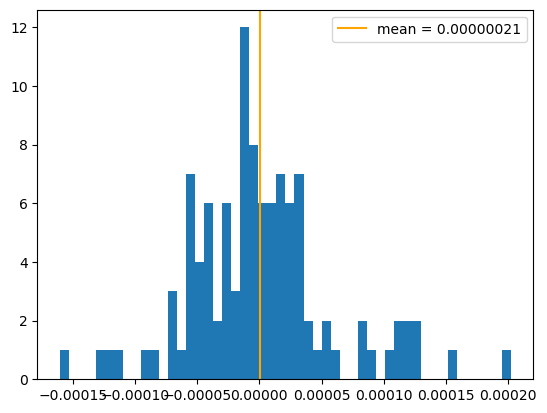

In [52]:
fig, ax = plt.subplots(1, 1)
_ = ax.hist(diff, bins=50)
ax.axvline(mean, label=f'mean = {mean:.8f}', color='orange')
ax.legend()
# Based on the plot, I would say half precision is okay!

## Convert it to an ONNX file

In [53]:
# Create dummy input with the correct shape
in_features = config['model']['in_features']
num_particles = config['data']['num_particles']
dummy_input = torch.randn(1, num_particles, in_features)

# Export to ONNX
torch.onnx.export(
    model,                      # model being run
    dummy_input,                # model input (or a tuple for multiple inputs)
    "mlp.onnx",                 # where to save the model (filename)
    export_params=True,         # store the trained weights inside the model
    opset_version=11,           # the ONNX version to export to (11 is widely supported)
    do_constant_folding=True,   # optimize constants
    input_names=['input'],      # input name (can be arbitrary)
    output_names=['output'],    # output name
    dynamic_axes={              # support dynamic batch size
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'},
    }
)

print("Model has been exported to ONNX format.")

Model has been exported to ONNX format.


## Load the ONNX model and check its validity

In [54]:
onnx_path = 'mlp.onnx' 
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)

print("ONNX model is valid!")

ONNX model is valid!


## Test the ONNX model with ONNX Runtime

In [55]:
ort_session = onnxruntime.InferenceSession(onnx_path)

# Numpy dummy input
input_data = dummy_input.numpy()

# Run the ONNX model
ort_inputs = {ort_session.get_inputs()[0].name: input_data}
ort_outputs = ort_session.run(None, ort_inputs)
print("ONNX model tested successfully!")

ONNX model tested successfully!


get one batch (contains 4 events since we set the `batch_size=4` in the data loader) and run PyTorch model

In [56]:
event = next(iter(dataloader))
# readout generated by the misaligned detectors
# "_cont" here means the coordinates are continuous without any rounding.
readout = event[f'readout_curr_cont'].to(device)
# readout: (batch_size, num_detectors, num_particles, 2)
#        ->(batch_size, num_particles, num_detectors, 2)
#        ->(batch_size, num_particles, num_detectors x 2)
readout = torch.transpose(readout, 1, 2).flatten(-2, -1)
torch_outputs = model(readout)

run the ONNX model

In [57]:
ort_inputs = {ort_session.get_inputs()[0].name: readout.numpy()}
ort_outputs = ort_session.run(None, ort_inputs)[0]

Compare PyTorch and ONNX outputs

In [58]:
difference = np.abs(torch_outputs.detach().numpy() - ort_outputs)
max_diff = np.max(difference)
print(f"Max difference between PyTorch and ONNX outputs: {max_diff:.6f}")

Max difference between PyTorch and ONNX outputs: 0.000000


## NEW: Convert submodules to ONNX files

In [68]:
# let us see what submodels we have
for name, module in model_half.named_children():
    print(f'== {name} ==================================')
    print(module)

== embed ==================================
Sequential(
  (0): Identity()
  (1): Linear(in_features=6, out_features=128, bias=True)
  (2): LeakyReLU(negative_slope=0.1)
  (3): Identity()
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): LeakyReLU(negative_slope=0.1)
)
== solvers ==================================
ModuleList(
  (0-2): 3 x SubsetSolver(
    (model): Sequential(
      (0): Identity()
      (1): Linear(in_features=768, out_features=128, bias=True)
      (2): LeakyReLU(negative_slope=0.1)
      (3): Linear(
        (norm_layer): Identity()
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (activ): LeakyReLU(negative_slope=0.1)
      )
      (4): Linear(
        (norm_layer): Identity()
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (activ): LeakyReLU(negative_slope=0.1)
      )
      (5): Linear(
        (norm_layer): Identity()
        (linear): Linear(in_features=128, out_features=128, bias=True

In [88]:
# Create dummy input for all submodels with the correct shape
num_particles = config['data']['num_particles']

in_features = config['model']['in_features']
embedding_features = config['model']['embedding_features']
# Note that the subset solvers all have the same config,
# and hence getting the configuration of the first one is enough.
subset_size = config['model']['subset_config'][0][0]
subset_features = config['model']['subset_config'][0][-1]

dummy_embed = torch.randn(1, num_particles, in_features)
dummy_solvers = torch.randn(1, num_particles, subset_size * embedding_features[-1])
dummy_output = torch.randn(1, num_particles, subset_features)

In [89]:
submodule_embed = model_half.get_submodule('embed')
submodule_solvers = [mod for mod in model_half.get_submodule('solvers')]
submodule_output = model_half.get_submodule('output')

In [91]:
# Let the conversion begin! 
torch.onnx.export(
    submodule_embed,
    dummy_embed.half(),
    "submodule_onnx/submodule_embed.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'},
    }
)

for i, mod in enumerate(submodule_solvers):
    torch.onnx.export(
        mod.model,
        dummy_solvers.half(),
        f"submodule_onnx/submodule_solvers-{i}.onnx",
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'},
        }
    )

torch.onnx.export(
    submodule_output,
    dummy_output.half(),
    "submodule_onnx/submodule_output.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'},
    }
)